In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "/home/nboley/src/fragmentomics_tools/projects/")

In [3]:
import os

import pandas as pd
import seaborn

from fragments_h5 import FragmentsH5

from fragmentomics_tools.dataframe import Region, RegionDataFrame, SampleAndRegionDataFrame
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays

from ibd.lib import load_ibd_sample_df, build_marker_gene_rdf

# Samples

In [4]:
sdf = load_ibd_sample_df()

In [5]:
sdf

,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER
365,RD-36403,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4
364,RD-36402,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8
337,RD-36063,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_8
338,RD-36064,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_4
339,RD-36065,0,<fragments_h5.fragments_h5.FragmentsH5 object ...,Asymptomatic,Asymptomatic,NaN,Site_7
...,...,...,...,...,...,...,...
320,RD-50565,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13
321,RD-50591,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 1,Site_13
322,RD-50592,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 2,Site_16
333,RD-56149,4,<fragments_h5.fragments_h5.FragmentsH5 object ...,Crohn's Disease,Severe,Patient Group 6,Site_7


# TSS Sites

In [6]:
from ibd.data import HematopoieticGeneExpression
hge_raw = HematopoieticGeneExpression.load()
repeats_rdf = RegionDataFrame.from_bed("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", ref=hge_raw.ref)
hge = hge_raw.drop_overlapping_regions(repeats_rdf)
tss_s = hge.truncate(right_amt=hge.region_lengths-1, strand_aware=True).resize_regions(256)

In [7]:
from fragmentomics_tools.bias_correction.model import BackgroundModelModule
model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.accessible_regions.negative_binomial.res').cuda()
# model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/merged.negative_binomial.merged.2.res').cuda()
pred = model.predict_from_rdf(tss_s)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2814/2814 [00:13<00:00, 210.24it/s]


In [8]:
rdf = tss_s.join(pred)
rdf

,gene_name,gene_id,contig,strand,start,stop,expression,pred_dist.strand_+__fl_40_65__coverage_first,pred_dist.strand_+__fl_40_65__coverage_last,pred_dist.strand_+__fl_40_65__coverage_midpoint,pred_dist.strand_+__fl_120_175__coverage_first,pred_dist.strand_+__fl_120_175__coverage_last,pred_dist.strand_+__fl_120_175__coverage_midpoint,pred_dist.strand_-__fl_40_65__coverage_first,pred_dist.strand_-__fl_40_65__coverage_last,pred_dist.strand_-__fl_40_65__coverage_midpoint,pred_dist.strand_-__fl_120_175__coverage_first,pred_dist.strand_-__fl_120_175__coverage_last,pred_dist.strand_-__fl_120_175__coverage_midpoint
8,RNF223,ENSG00000237330,chr1,-,1072447,1072703,0.000000,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
12,TNFRSF4,ENSG00000186827,chr1,-,1214025,1214281,1.777118,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
14,B3GALT6,ENSG00000176022,chr1,+,1232109,1232365,30.786345,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
19,TAS1R3,ENSG00000169962,chr1,+,1331152,1331408,0.312580,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
22,AURKAIP1,ENSG00000175756,chr1,-,1374662,1374918,263.953149,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...,<scipy.stats._distn_infrastructure.rv_discrete...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17339,F8A

In [9]:
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = sdf.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fragmentomics_tools.plot.tracks import CoverageTrack, VLine, Tracks, VectorTrack, VplotTrack, StrandSplitCoverageTrack

def make_tracks_from_fa(fa, extra_tracks=False, include_cutsites=False, include_vplot=False):
    region_size = fa.shape[1]

    smooth_window = 5
    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for strand in ['+', '-']:
        sub_fa = fa.subset_by_fragment_strand(strand)
        for frag_lens in ((40, 60), (80, 500)):
            tracks.append(
                CoverageTrack(sub_fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=frag_lens, smooth_window=smooth_window, 
                              vlines=[VLine(x=region_size//2)], 
                              name=f'fraglens: {frag_lens} strand: {strand} left endpoint') 
                + CoverageTrack(sub_fa, fa.plot_region, coverage_type='right_endpoint', n_boot_coverage=0, fraction=frag_lens, smooth_window=smooth_window, 
                                vlines=[VLine(x=region_size//2)], 
                                name=f' - right endpoint'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=10, fraction=(20, 40), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='Very Small Peak (20 - 40)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=10, fraction=(40, 60), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='50 BP Peak (40 - 60)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=10, fraction=(80, 500), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='50 BP Peak (80 - 500)'))  
    """
    if extra_tracks:
        tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(20, 40), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='Very Small Peak (20 - 40)'))
        tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(40, 60), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='50 BP Peak (40 - 60)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(60, 100), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='sub-nucleosome (60 - 100)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=(110, 500), smooth_window=500, ylim=(0, None),
                                #vlines=[VLine(x=region_size//2+first_nuc+x*offset) for x in range(8)] + [VLine(x=region_size//2-first_nuc-x*offset) for x in range(8)], 
                                name='nucleosome (> 110)'))
    """
    return tracks

In [10]:
rdf.query("expression > 20 and strand == '+'").shape

(440, 19)

# TSS Analysis

In [11]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(rdf.query("strand == '+'"), sdf).attach_fragment_arrays(num_cores=24)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 383690/383690 [05:07<00:00, 1247.08it/s]


In [12]:
import scipy
from fragmentomics_tools.bias_correction.data import build_counts
count_columns = [x[len("pred_dist."):] for x in srdf.columns if x.startswith("pred_dist.")]
# tmp_obs = srdf.query("expression > 20").head(100).df.progress_apply(lambda x: build_counts(x).apply(scipy.sparse.coo_array), axis=1)

In [13]:
srdf.query("expression > 20").shape

(134200, 27)

In [14]:
%%time
res = srdf.parallel_apply(lambda rec: build_counts(rec, return_sparse=True), n_workers=32)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 383690/383690 [01:49<00:00, 3513.75it/s]


CPU times: user 1min 58s, sys: 13.8 s, total: 2min 12s
Wall time: 2min 12s


In [50]:
def make_tracks(cov):
    # first make the midpoint tracks
    small_mp = VectorTrack(cov['strand_+__fl_40_65__coverage_midpoint'], name='midpoint forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_40_65__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=False)
    big_mp = VectorTrack(cov['strand_+__fl_120_175__coverage_midpoint'], name='midpoint forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_120_175__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=False)
    
    small_left = VectorTrack(cov['strand_+__fl_40_65__coverage_first'], name='first forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_40_65__coverage_first'], color='green', name='first reverse strand', smooth=False)
    big_left = VectorTrack(cov['strand_+__fl_120_175__coverage_first'], name='first forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_120_175__coverage_first'], color='green', name='first reverse strand', smooth=False)

    small_right = VectorTrack(cov['strand_+__fl_40_65__coverage_last'], name='last forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_40_65__coverage_last'], color='green', name='last reverse strand', smooth=False)
    big_right = VectorTrack(cov['strand_+__fl_120_175__coverage_last'], name='last forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_120_175__coverage_last'], color='green', name='last reverse strand', smooth=False)

    tracks = Tracks([small_left, small_right])
    return tracks
    for c in cov.index:
        tracks.append(VectorTrack(cov[c], name=c, smooth=False))
    return tracks

In [46]:
tmp = srdf.df.join(res)

(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

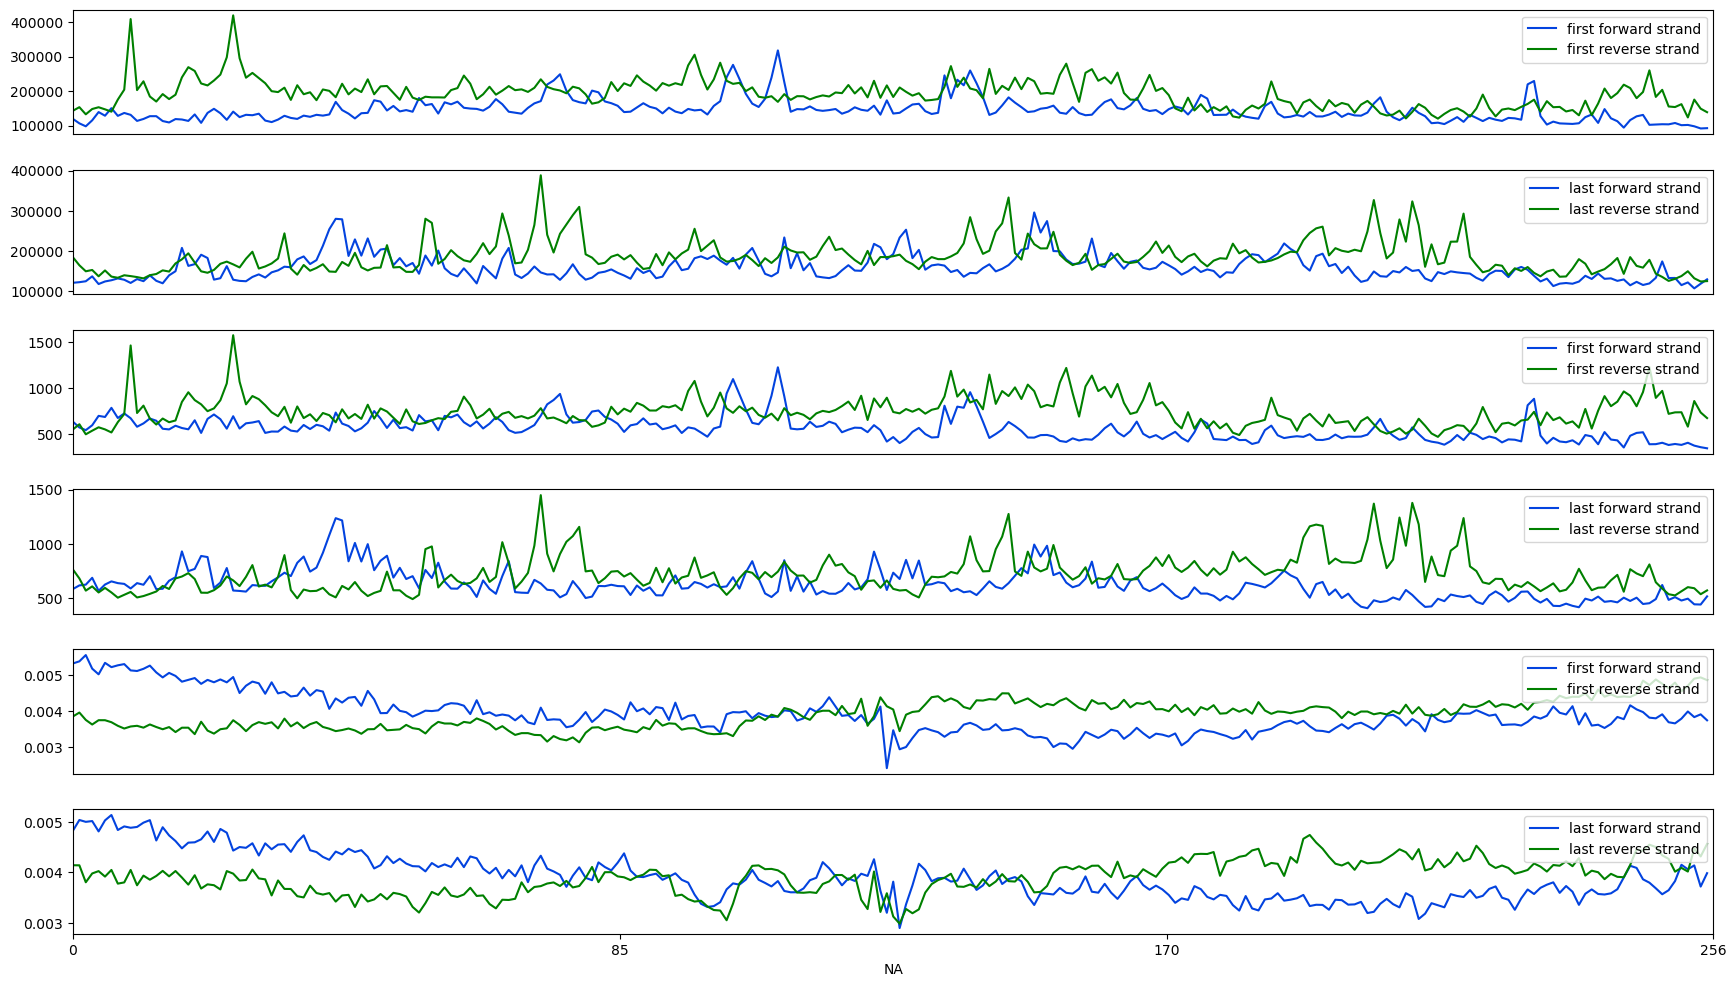

In [51]:
all_tracks = Tracks()
all_tracks.extend(make_tracks(pd.Series(list((on_cnts.values/on_pred.values)), index=on_cnts.index)))
all_tracks.extend(make_tracks(on_cnts))
all_tracks.extend(make_tracks(pd.Series(dict(on_pred).values(), index=on_cnts.index)))
all_tracks.plot()

(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

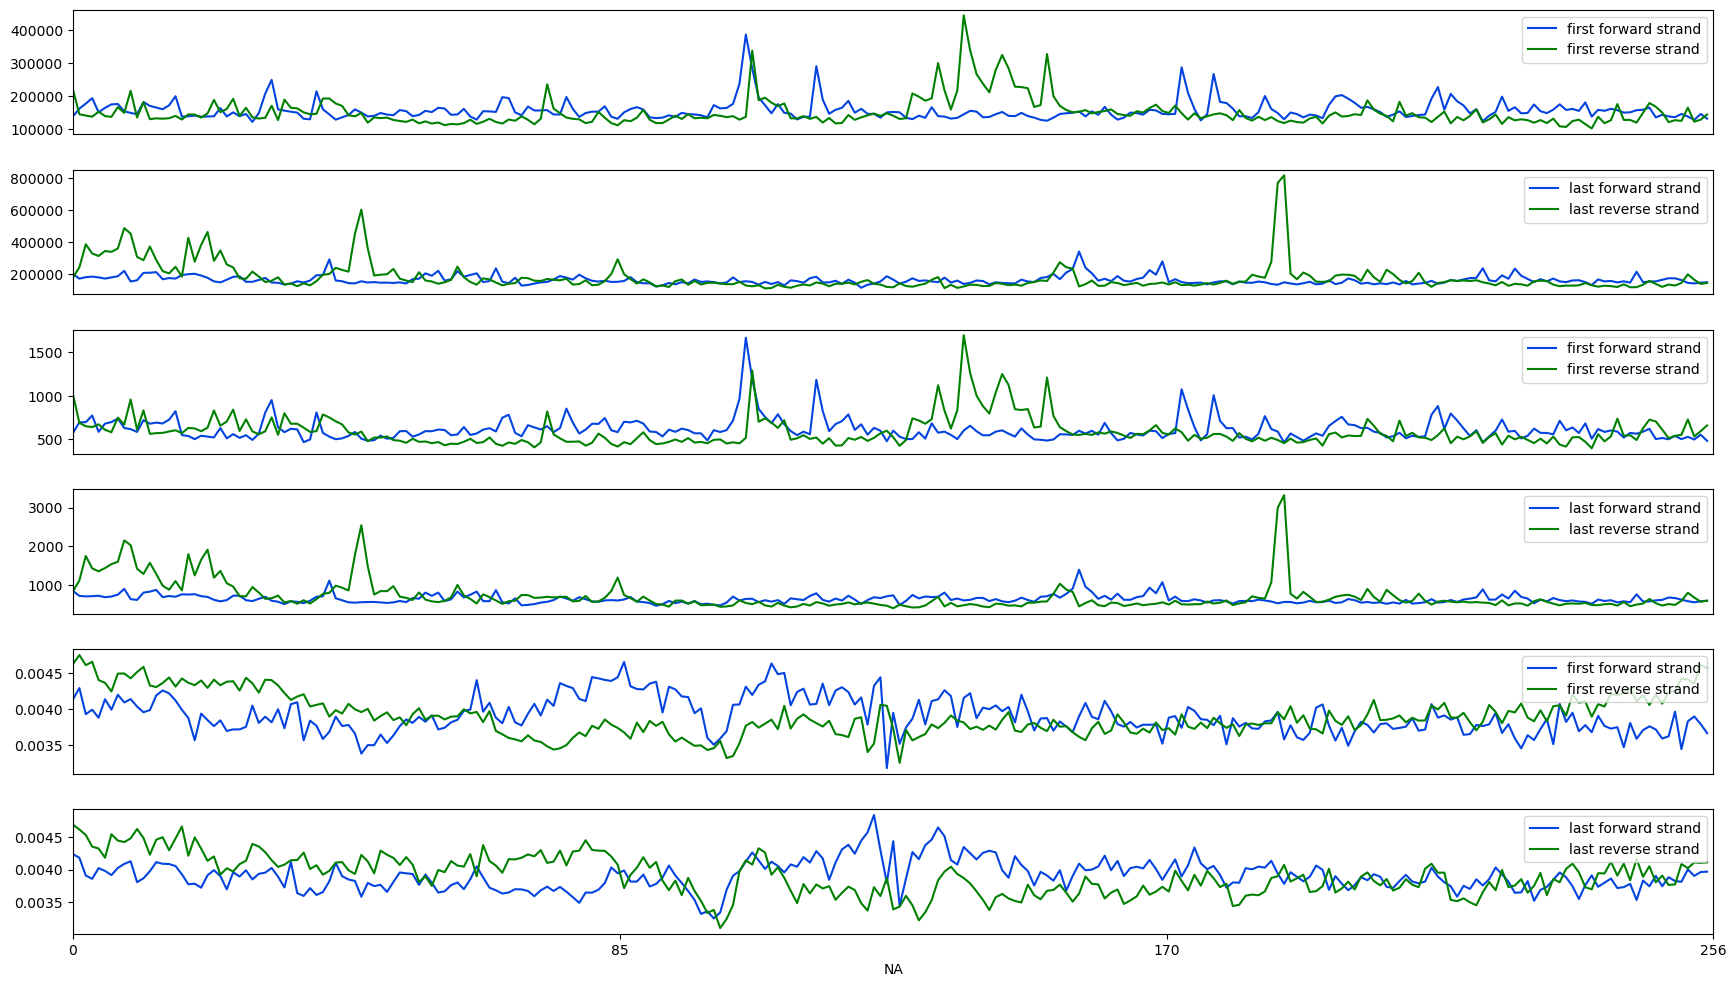

In [52]:
all_tracks = Tracks()
all_tracks.extend(make_tracks(pd.Series(list((off_cnts.values/off_pred.values)), index=off_cnts.index)))
all_tracks.extend(make_tracks(off_cnts))
all_tracks.extend(make_tracks(pd.Series(dict(off_pred).values(), index=off_cnts.index)))
all_tracks.plot()BEST4BEST4

CPU times: user 6min 20s, sys: 5.49 s, total: 6min 26s
Wall time: 6min 23s


(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

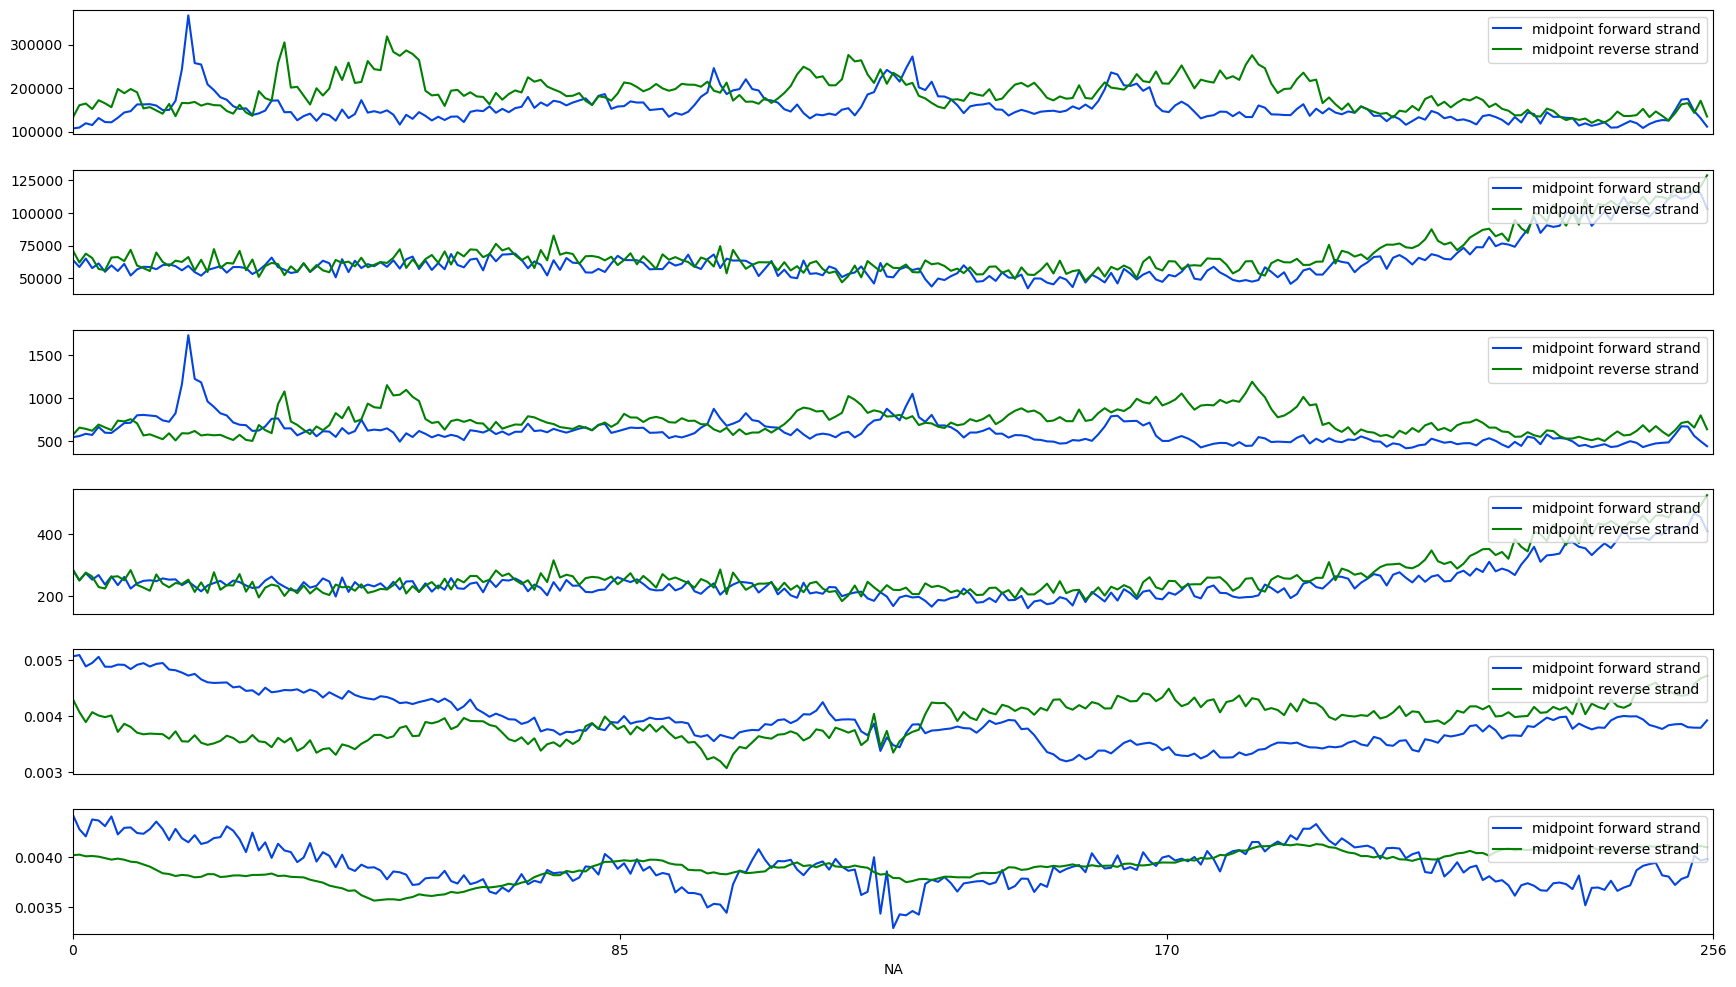

In [32]:
%%time
_sub_tmp = tmp.query("expression  > 20") 
on_pred = _sub_tmp[["pred_dist." + c for c in count_columns]].apply(lambda rec: pd.Series({c: rec[c].mean()/rec[c].mean().sum() for c in rec.index})).sum()/len(_sub_tmp)
on_cnts = _sub_tmp[count_columns].sum().apply(lambda x: x.todense().ravel())

all_tracks = Tracks()
all_tracks.extend(make_tracks(pd.Series(list((on_cnts.values/on_pred.values)), index=on_cnts.index)))
all_tracks.extend(make_tracks(on_cnts))
all_tracks.extend(make_tracks(pd.Series(dict(on_pred).values(), index=on_cnts.index)))
all_tracks.plot()

CPU times: user 6min 21s, sys: 4.98 s, total: 6min 26s
Wall time: 6min 23s


(<Figure size 2500x1200 with 6 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

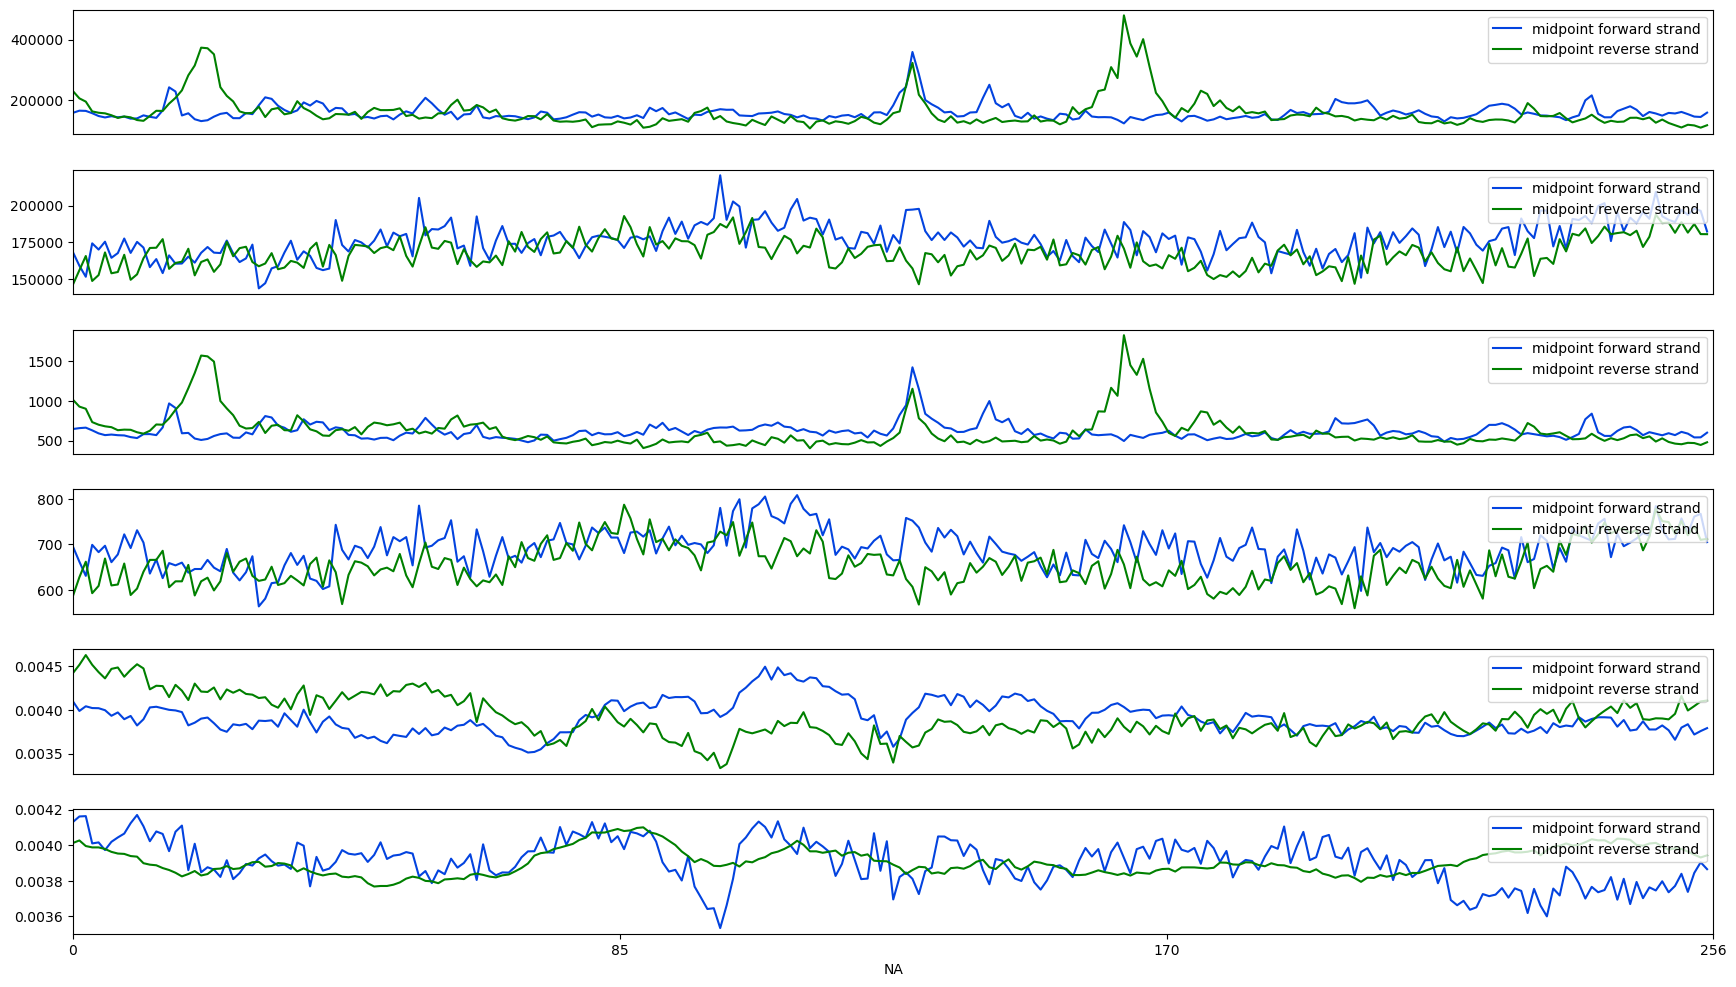

In [33]:
%%time
_sub_tmp = tmp.query("expression  < 0.1") 
off_pred = _sub_tmp[["pred_dist." + c for c in count_columns]].apply(lambda rec: pd.Series({c: rec[c].mean()/rec[c].mean().sum() for c in rec.index})).sum()/len(_sub_tmp)
off_cnts = _sub_tmp[count_columns].sum().apply(lambda x: x.todense().ravel())

all_tracks = Tracks()
all_tracks.extend(make_tracks(pd.Series(list((off_cnts.values/off_pred.values)), index=off_cnts.index)))
all_tracks.extend(make_tracks(off_cnts))
all_tracks.extend(make_tracks(pd.Series(dict(off_pred).values(), index=off_cnts.index)))
all_tracks.plot()

(<Figure size 2500x800 with 4 Axes>,
 [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='NA'>])

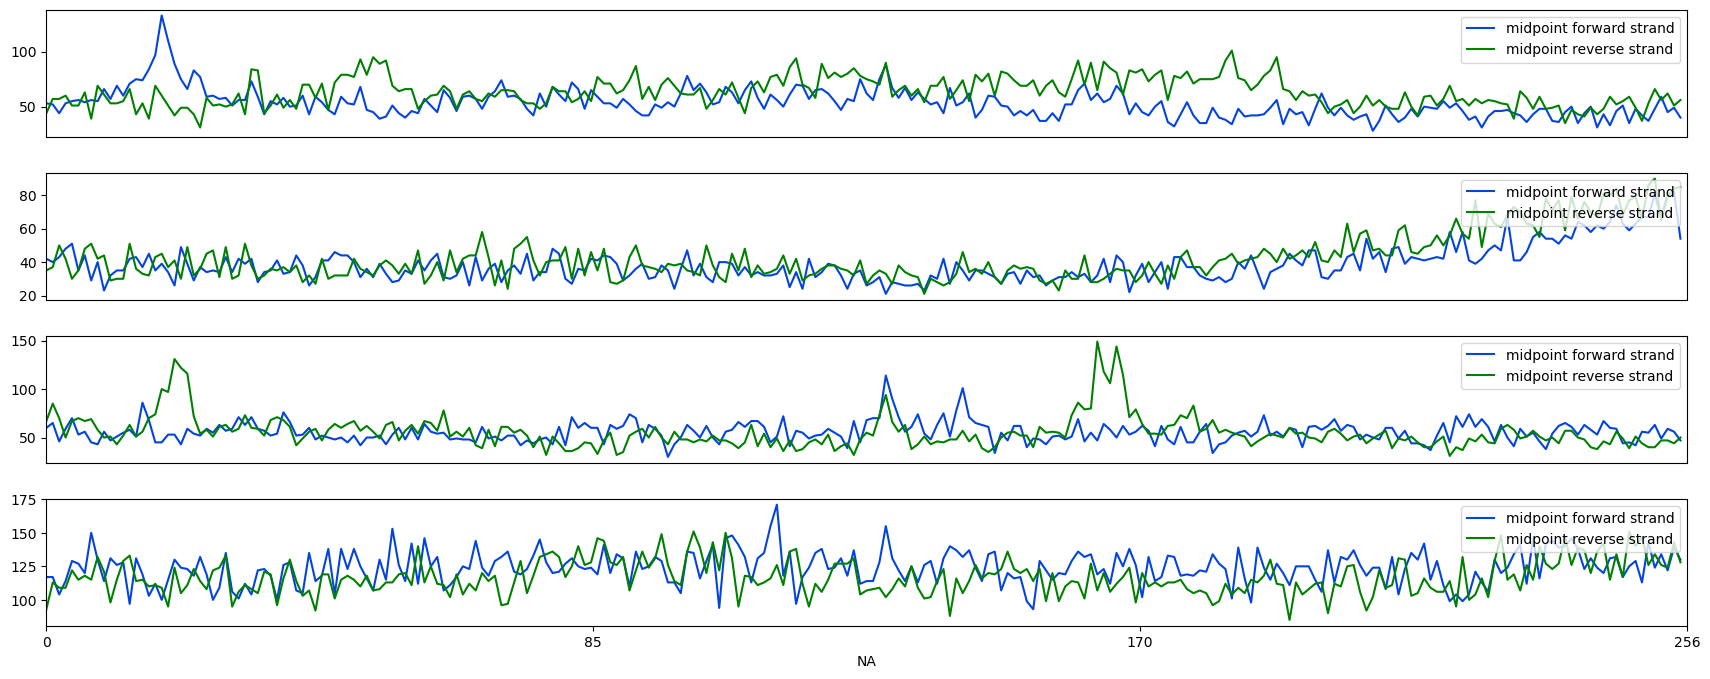

In [31]:
all_tracks = Tracks()
all_tracks.extend(make_tracks(on_cnts))
all_tracks.extend(make_tracks(off_cnts))
all_tracks.plot()

In [20]:
def make_tracks(cov):
    # first make the midpoint tracks
    small_mp = VectorTrack(cov['strand_+__fl_40_65__coverage_midpoint'], name='midpoint forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_40_65__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=False)
    big_mp = VectorTrack(cov['strand_+__fl_120_175__coverage_midpoint'], name='midpoint forward strand', smooth=False) + VectorTrack(cov['strand_-__fl_120_175__coverage_midpoint'], color='green', name='midpoint reverse strand', smooth=False)
    tracks = Tracks([small_mp, big_mp])
    return tracks
    for c in cov.index:
        tracks.append(VectorTrack(cov[c], name=c, smooth=False))
    return tracks

In [27]:
marker_genes

,index,gene_id,contig,strand,start,stop,expression,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,direction
0,BEST4,ENSG00000142959,chr1,-,44783585,44788170,0.368135,1.959212e-108,-4.169254,0.006,0.042,5.729519e-104,up_in_colon
1,CD2,ENSG00000116824,chr1,+,116754430,116755021,10.122990,0.000000e+00,7.402749,0.112,0.001,0.000000e+00,down_in_colon
2,FCRLA,ENSG00000132185,chr1,+,161706972,161713452,3.823114,3.256510e-59,8.585422,0.021,0.000,9.523338e-55,down_in_colon
3,NLRP3,ENSG00000162711,chr1,+,247418053,247425792,37.178351,1.154279e-49,9.489926,0.017,0.000,3.375574e-45,down_in_colon
4,TBC1D10C,ENSG00000175463,chr11,+,67403915,67410089,76.448981,1.602647e-260,7.835757,0.090,0.001,4.686782e-256,down_in_colon
5,TESPA1,ENSG00000135426,chr12,-,54948015,54966151,47.577006,3.752280e-236,7.613294,0.082,0.001,1.097317e-231,down_in_colon
6,ARHGAP9,ENSG00000123329,chr12,-,57472264,57477680,68.457228,2.949238e-156,8.289623,0.056,0.001,8.624753e-152,down_in_colon
7,SNX22,ENSG00000157734,chr15,+,64151731,64157481,5.201860,2.109755e-53,7.222411,0.020,0.001,6.169766e-49,down_in_colon
8,ITGAX,ENSG00000140678,chr16,+,31355174,31358455,23.315588,7.693366e-134,7.249486,0.049,0.001,2.249848e-129,down_in_colon
9,CCR7,ENSG00000126353,chr17,-,40553769,40558942,3.997845,4.469245e-219,10.802147,0.075,0.000,1.306986e-214,down_in_colon


In [21]:
marker_genes = build_marker_gene_rdf(hge)
on_gene_ids = marker_genes.query("direction == 'up_in_colon'").gene_id.tolist()
off_gene_ids = marker_genes.query("direction == 'down_in_colon'").gene_id.tolist()
on_in_colon = tmp.query("gene_id in @on_gene_ids")
off_in_colon = tmp.query("gene_id in @off_gene_ids")

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

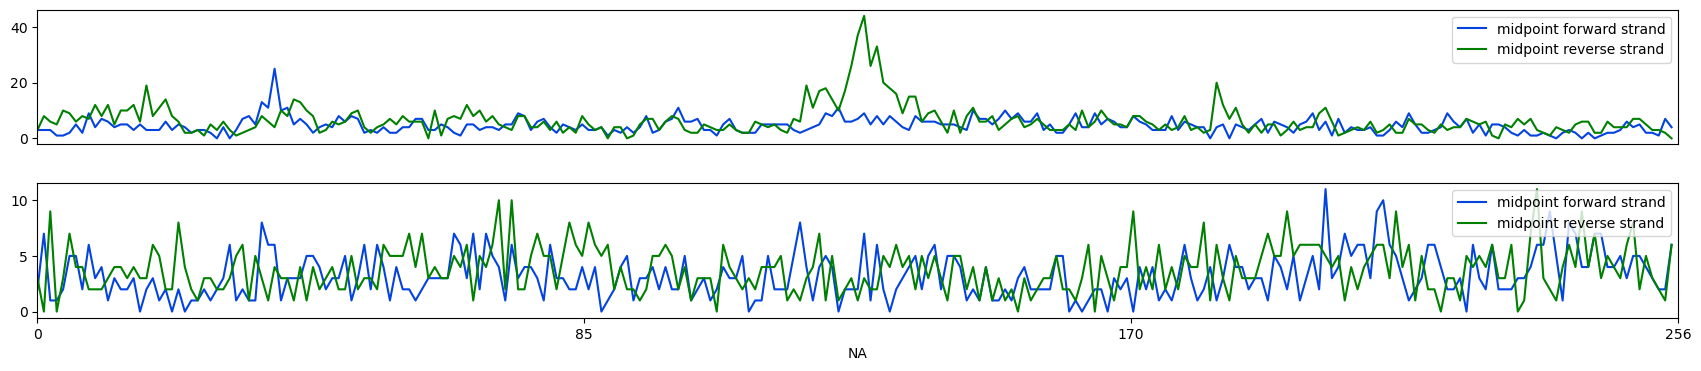

In [22]:
make_tracks(off_in_colon.query("label == 1")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

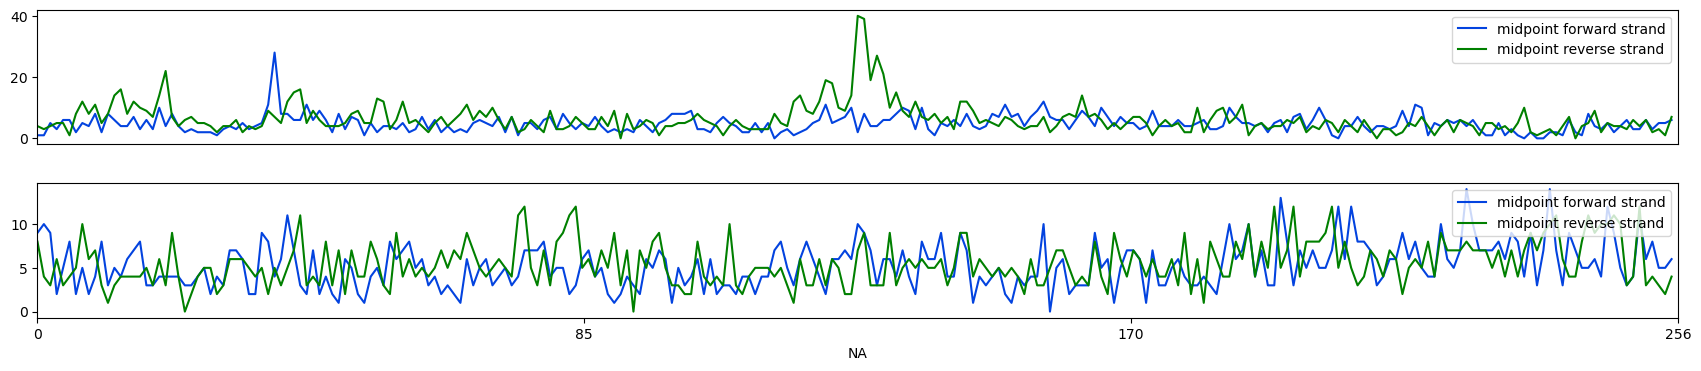

In [23]:
make_tracks(off_in_colon.query("label >= 3")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

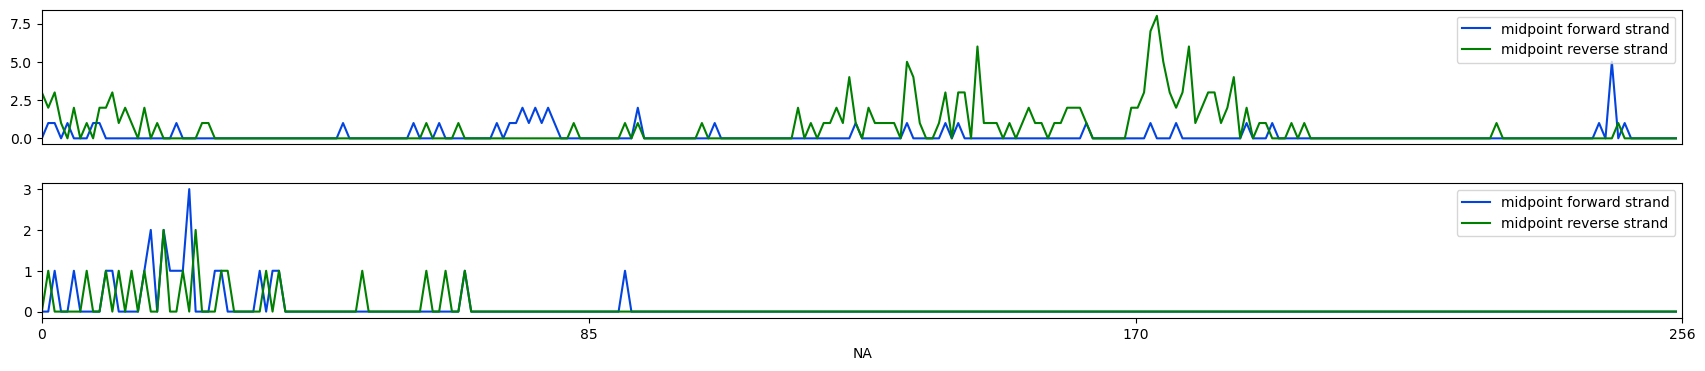

In [24]:
make_tracks(on_in_colon.query("label == 1")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

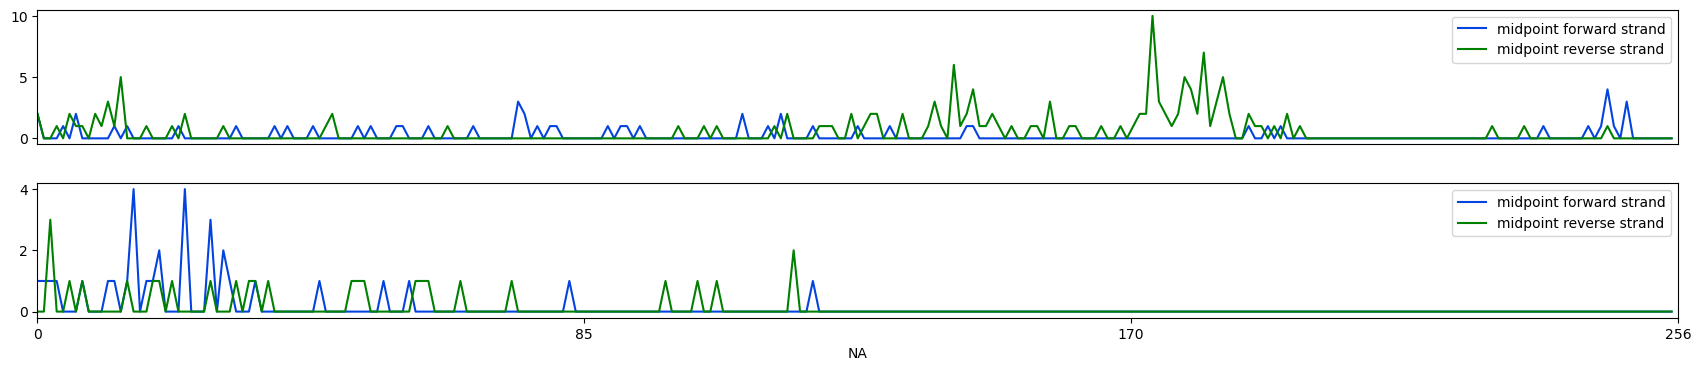

In [25]:
make_tracks(on_in_colon.query("label >= 3")[count_columns].sum().apply(lambda x: x.todense().ravel())).plot()

 # Corrected

In [41]:
def build_normalized_counts(record):
    fa = record.fragment_array.drop_duplicate_fragments()
    pseudo_count = 1./record.fragment_array.length

    # subset_by_fragment_strand('+')
    fwd_cov = fa.subset_fragment_lengths(40, 60).first_covered_base_counts
    fwd_means = record.fwd_start_counts_dist.mean()
    fwd_cov_pred = fwd_cov.sum()*(fwd_means/fwd_means.sum())

    # .subset_by_fragment_strand('-')
    bkwd_cov = fa.subset_fragment_lengths(40, 60).last_covered_base_counts
    bkwd_means = record.bkwd_stop_counts_dist.mean()
    bkwd_cov_pred = bkwd_cov.sum()*(bkwd_means/bkwd_means.sum())

    fwd_bkwd_ratio = fwd_means.sum()/bkwd_means.sum()
    
    fwd_cov_norm = fwd_cov/(fwd_cov_pred.clip(pseudo_count, None))
    fwd_cov_norm *= fwd_cov.sum()/(fwd_cov_norm.sum()+1e-6)

    bkwd_cov_norm = bkwd_cov/(bkwd_cov_pred.clip(pseudo_count, None))
    bkwd_cov_norm *= bkwd_cov.sum()/(bkwd_cov_norm.sum()+1e-6)

    return pd.Series(dict(fwd_cov=fwd_cov, fwd_cov_pred=fwd_cov_pred, fwd_cov_norm=fwd_cov_norm, bkwd_cov=bkwd_cov, bkwd_cov_pred=bkwd_cov_pred, bkwd_cov_norm=bkwd_cov_norm))

def build_aggregated_coverage(srdf):
    tmp = srdf.df.apply(build_counts, axis=1)
    df = pd.DataFrame(list(tmp.sum())).T
    df.columns = tmp.columns
    return df

In [ ]:
counts = srdf.df.progress_apply(build_counts, axis=1)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 383645/383690 [05:45<00:00, 1125.77it/s]

In [28]:
from fragmentomics_tools.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack, StrandSplitCoverageTrack, VectorTrack


(<Figure size 2500x800 with 5 Axes>,
 [<Axes: title={'center': ' 8205764 frags'}>, <Axes: >, <Axes: xlabel='NA'>])

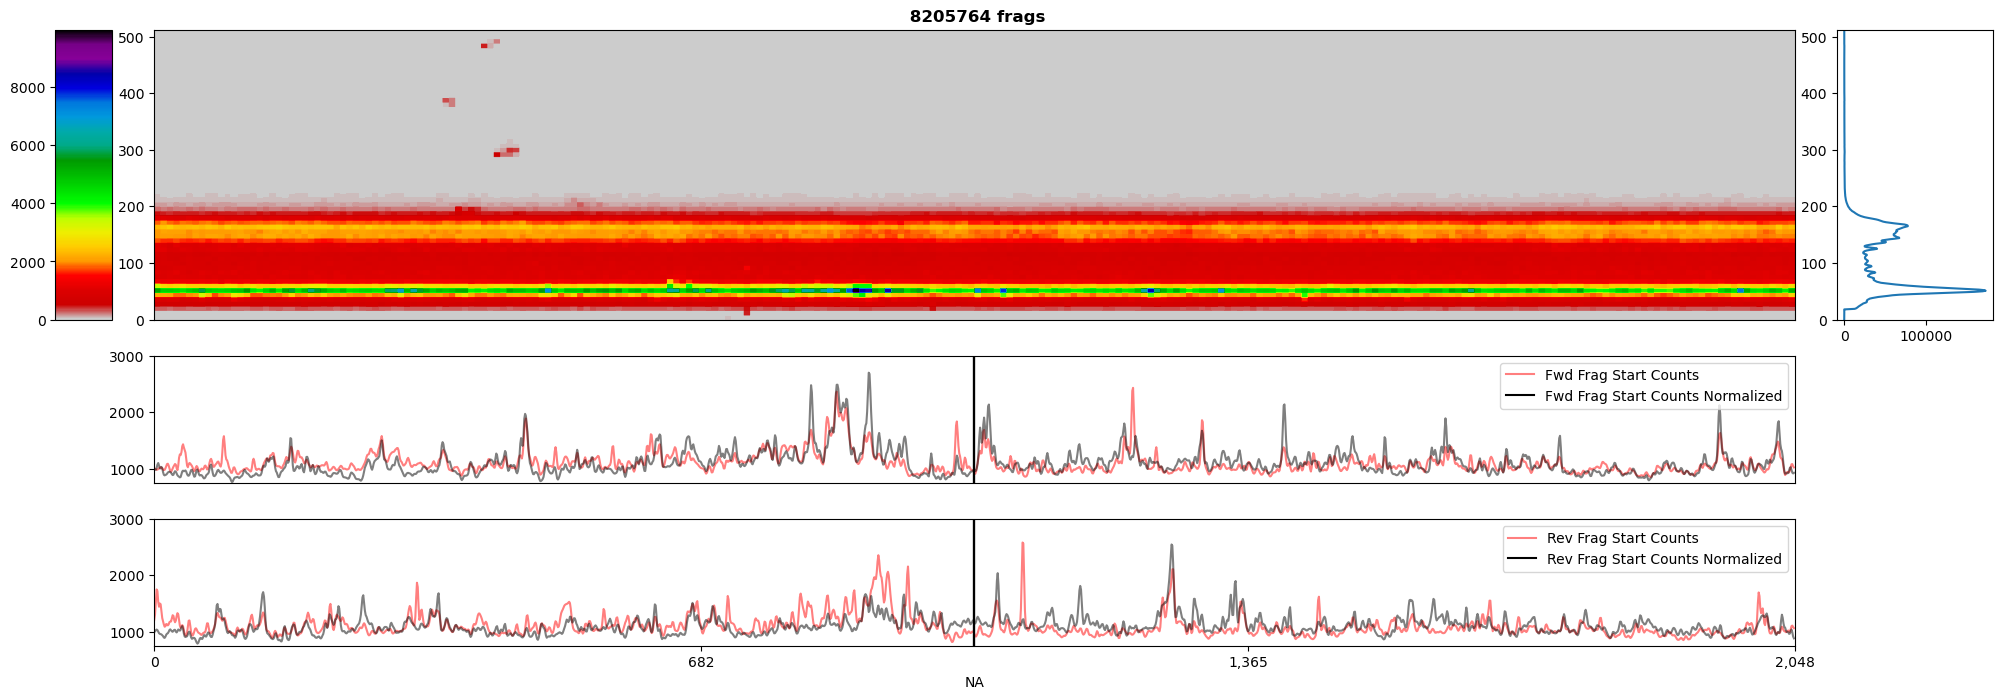

In [34]:
sm_win_len = 5
ylim = (750, 3000)
tracks = Tracks()
tracks.append(VplotTrack(fa, sum_pool_by=8))
tracks.append(
    VectorTrack(tmp.fwd_cov.sum(), color='red', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Fwd Frag Start Counts', vlines=[VLine(x=1024)]) \
    + VectorTrack(tmp.fwd_cov_norm.sum(), color='black', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Fwd Frag Start Counts Normalized')
)
tracks.append(
    VectorTrack(tmp.bkwd_cov.sum(), color='red', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Rev Frag Start Counts', vlines=[VLine(x=1024)]) \
    + VectorTrack(tmp.bkwd_cov_norm.sum(), color='black', smooth=True, smooth_window_len=sm_win_len, alpha=0.5, ylim=ylim, name='Rev Frag Start Counts Normalized')
)
tracks.plot()

(<Figure size 2500x1400 with 7 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: xlabel='NA'>])

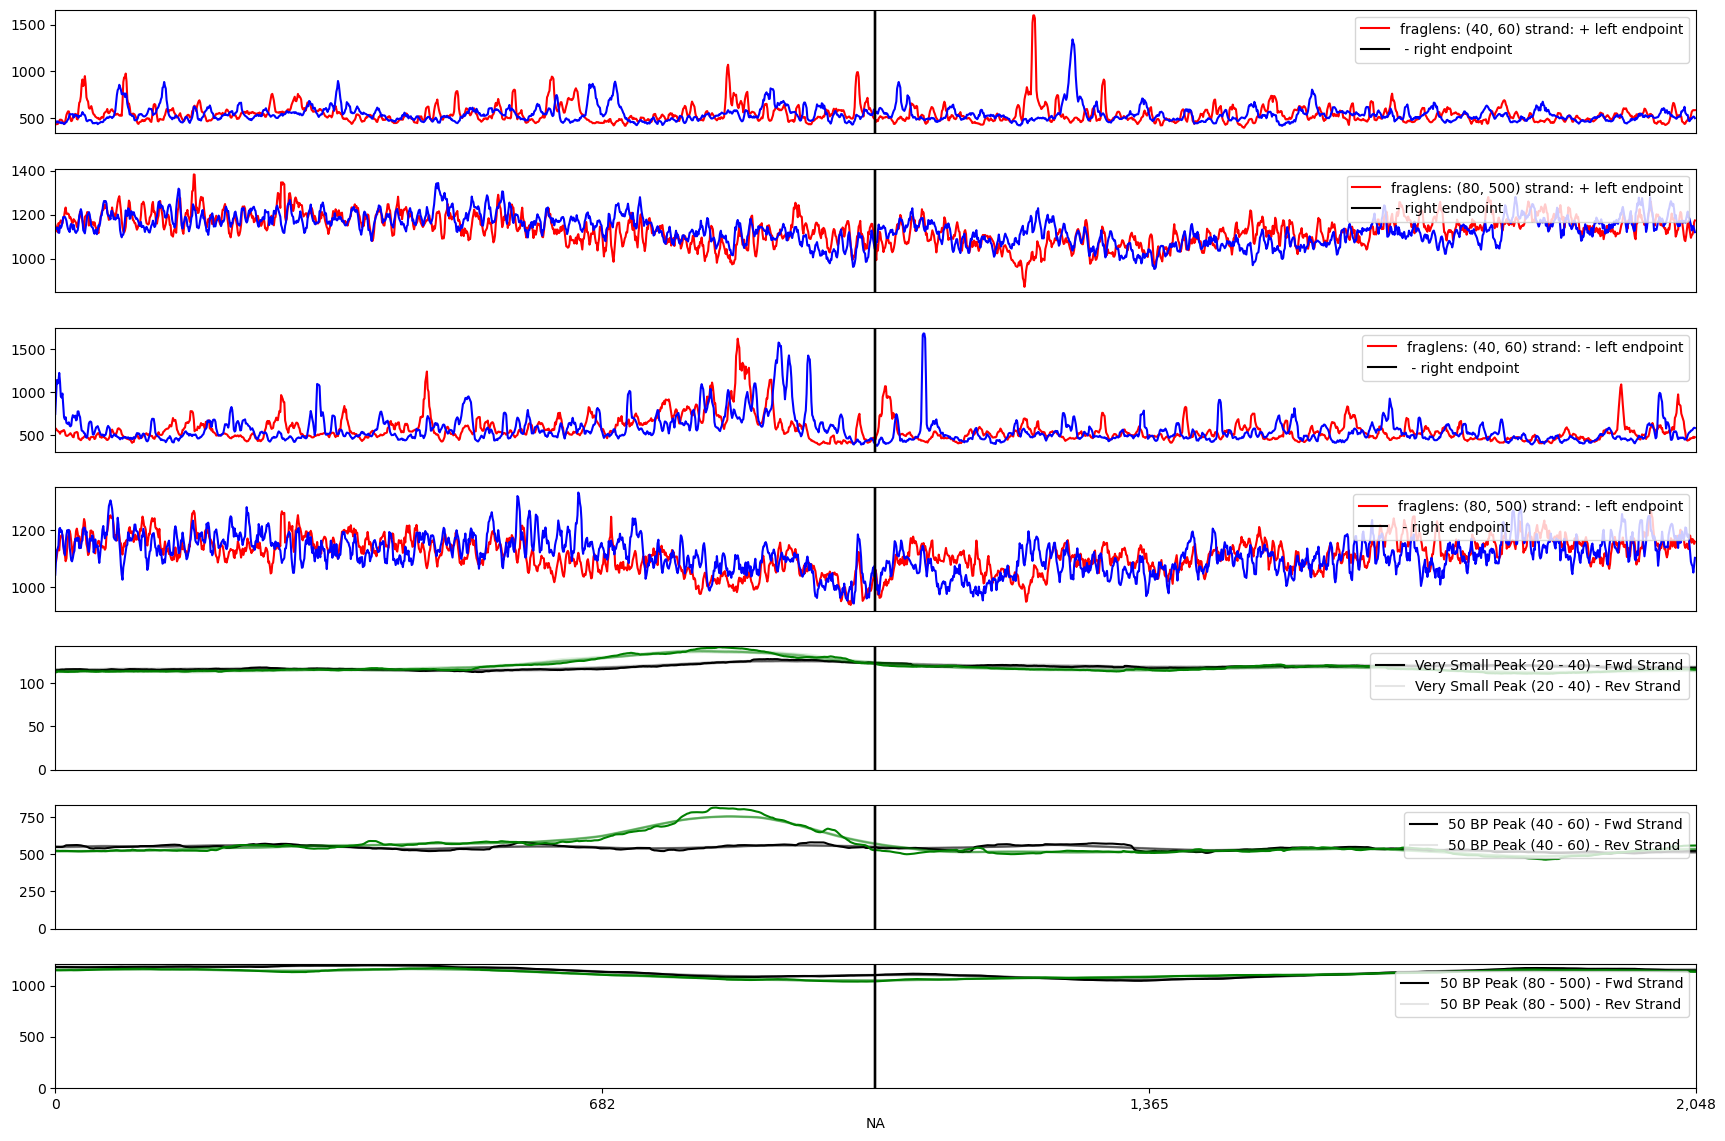

In [32]:
make_tracks(fa).plot()

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='NA'>])

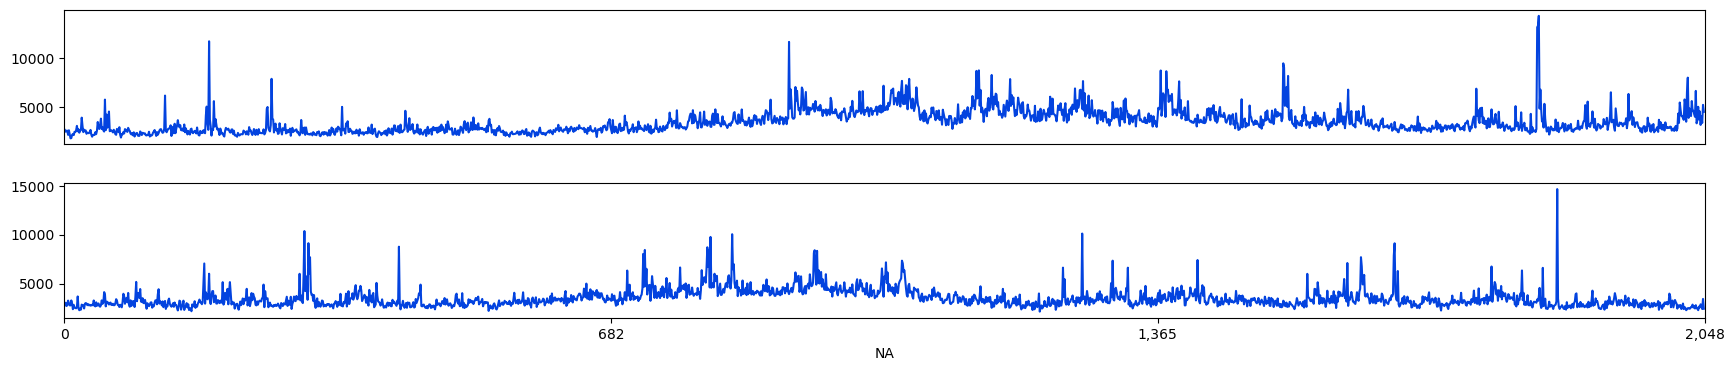

In [71]:
tracks = Tracks()
tracks.append(VectorTrack(tmp.fwd_cov_norm.sum()))
tracks.append(VectorTrack(tmp.bkwd_cov_norm.sum()))
tracks.plot()

(<Figure size 2500x1400 with 7 Axes>,
 [<Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: xlabel='NA'>])

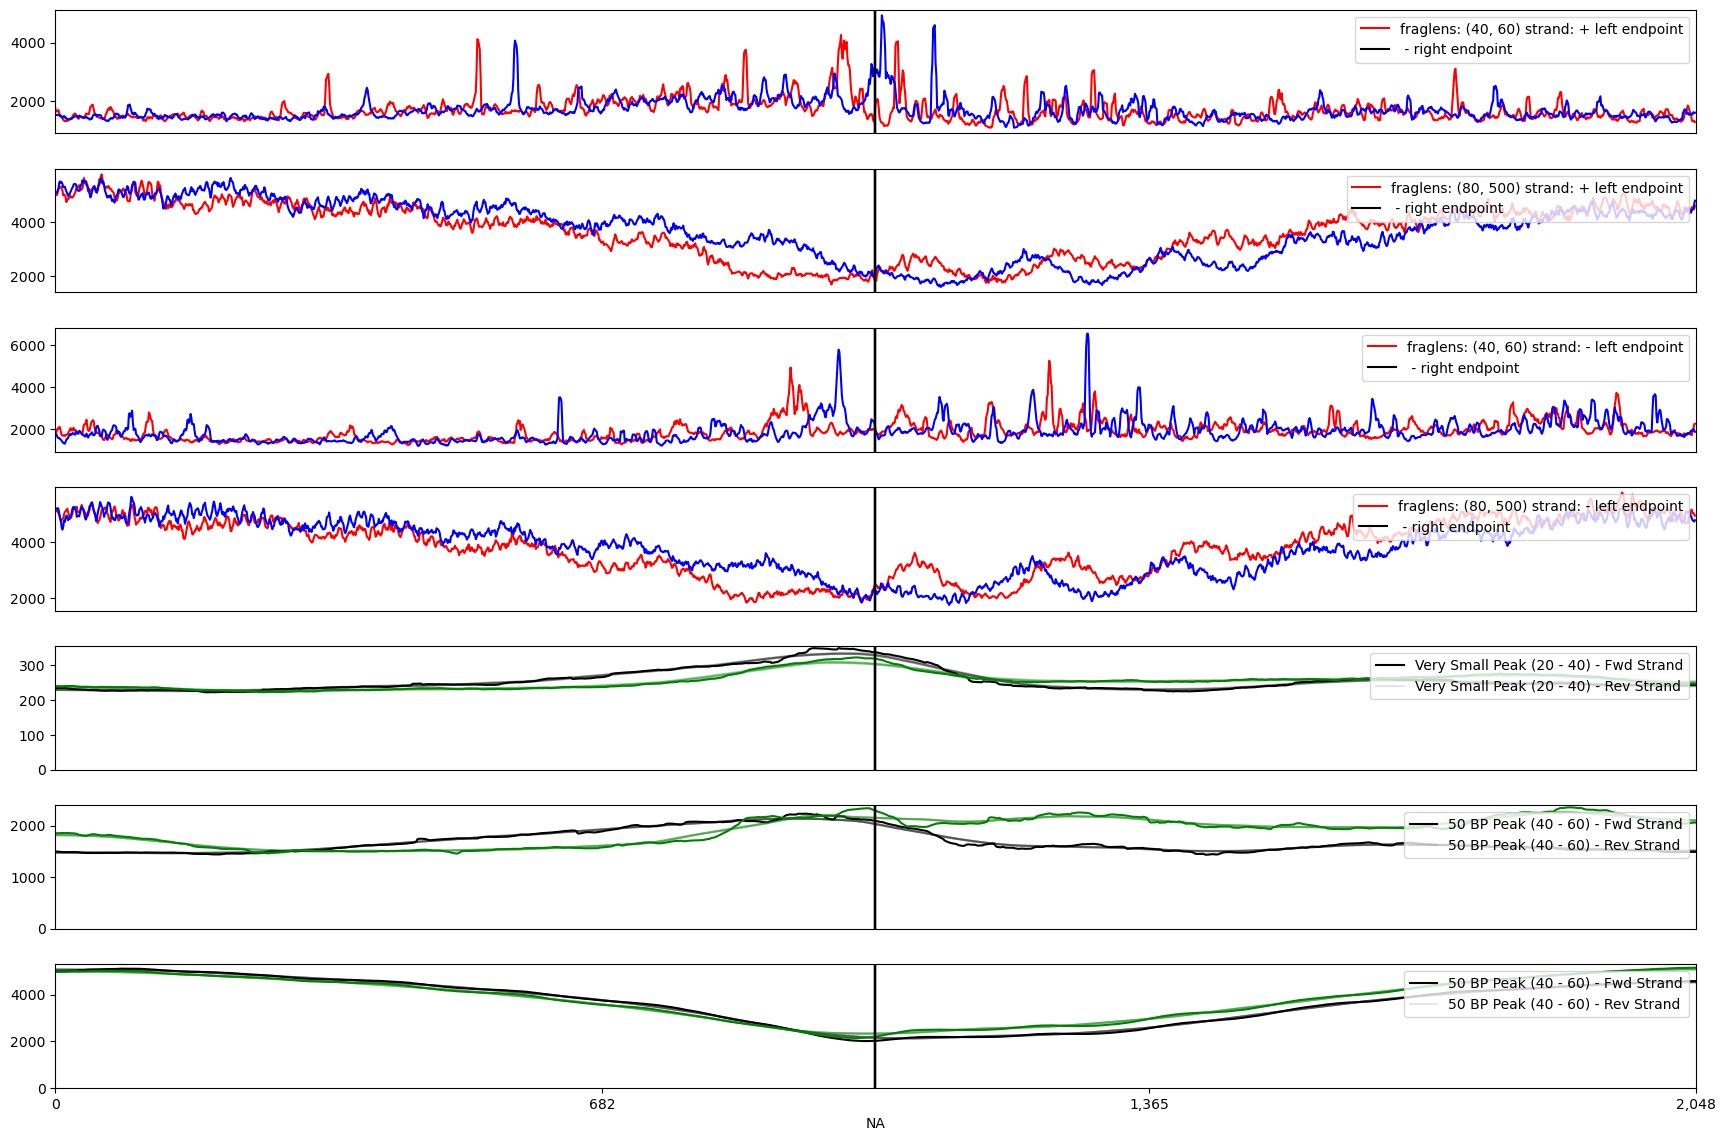

In [33]:
make_tracks(fa).plot()

In [17]:
def get_labeled_tss_s():
    filtered_tss_s = tss_s.query("num_tss_in_gene == 1").merge_gene_expression(gene_expression).copy()

    blood_labels = filtered_tss_s.set_binary_label_by_thresholds(
        blood_cell_eids[6],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('blood_label')

    gi_labels = filtered_tss_s.set_binary_label_by_thresholds(
        gi_cell_eids[:1],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('gi_label')


    filtered_tss_s.loc[:, 'cell_type'] = None
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 1), 'cell_type'] = 'all'
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 0), 'cell_type'] = 'gi'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 1), 'cell_type'] = 'blood'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 0), 'cell_type'] = 'none'

    filtered_tss_s['gene_id'] = filtered_tss_s.id.str.extract('(ENSG\d+)\..+')

    filtered_tss_s = filtered_tss_s.dropna().reset_index(drop=True)
    
    return filtered_tss_s

In [531]:
filtered_tss_s = get_labeled_tss_s()
filtered_tss_s.cell_type.value_counts()

[autoreload of ravel.fragment_array failed: Traceback (most recent call last):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 480, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 329, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", li

none     1850
all       663
gi         61
blood       8
Name: cell_type, dtype: int64

In [19]:
filtered_tss_s, counts, fragment_stats = make_counts_and_region_stats(filtered_tss_s, sample_ids_to_samples)

  6%|██████████████████                                                                                                                                                                                                                                                                                                                    | 1/18 [00:06<01:42,  6.05s/it]


KeyboardInterrupt: 

In [ ]:
filtered_tss_s.cell_type.value_counts()

In [ ]:
# filtered_tss_s.query("cell_type == 'all'")
fa, fas = fa_from_rdf(filtered_tss_s.query("cell_type == 'all'"), FragmentsH5(sample_ids_to_samples['RD-56167']), region_size=4096, downsample_size=None, fl_normalize=False)

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'all'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Active TSS's over ALL IBD Samples")

In [ ]:
none_fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'none'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(none_fa, True, True, True).plot(title="In-Active TSS's over ALL IBD Samples")

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'blood'"), region_size=4096, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Blood TSS's over ALL IBD Samples")

In [ ]:
list(filtered_tss_s.cell_type.unique())

In [ ]:
for cell_type in filtered_tss_s.cell_type.unique():
    make_tracks(fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == @cell_type").sample(90), region_size=4096, fl_normalize=False, max_num_samples=12), extra_tracks=True).plot(title=f'TSS Expressed in {cell_type.upper()} across All Samples')

# Simulations

In [ ]:
RegionFragmentArray.from_fragments_h5("/scratch/test_samples/SEQRUN48_LIBRARY574.fragments.h5", Region.from_region_str("chr1:91419-91436").resize(1024))

In [ ]:
neg_density = fm_from_regions_mask(only_neural_mask).sum_pooled(1).dense_array.clip(1e-5)
neg_density = neg_density/neg_density.sum()

In [ ]:
pos_density = fm_from_regions_mask(only_blood_mask).sum_pooled(1).dense_array.clip(1e-5)
pos_density = pos_density/pos_density.sum()

In [ ]:
neg_density.ravel()

In [ ]:
from numpy.random import multinomial as sample_multinomial
from scipy.stats import multinomial as multinomal_density
def sample(p, n):
    x = sample_multinomial(n, p.ravel())
    x.resize(p.shape)
    return x

In [ ]:
n = 10000
disease_frac = 0.5
true = disease_frac*pos_density + (1-disease_frac)*neg_density
obs = sample(true, n)

multinomal_density.logpmf(obs.ravel(), obs.sum(), true.ravel())

In [ ]:
true.shape, obs.shape

In [ ]:
import numpy
numpy.random.rand(100)

# Gene Analysis

In [20]:
# use the gencode basic gtf to find all exonic regions 
# filter by: gene_type "protein_coding"
# find all genes by 
# merge all exons by gene
# take the gene end to be the first poly(A) tail (or the nearest end of the transcript)
# save into a region data frame, and attach fragment matrices
# build the coverage plots banded by fragment size
# stich these together, making sure that the fragment midpoint overlaps the exon
# make some plots!!!

In [416]:
%%time
gencode_df = pd.read_table(
    "/scratch/nboley/gencode/gencode.v39.basic.annotation.protein_coding.gff3",
    usecols=[0, 2, 3, 4, 6, 8],
    names=["contig", "element", "start", "stop", "strand", "meta"],
).query("contig not in ['chrM', 'chrY'] and element in ['transcript', 'exon', 'three_prime_UTR', 'five_prime_UTR']")
gencode_df['gene_id'] = gencode_df.meta.str.extract(';gene_id=(ENSG?\d+)\.\d+;')
gencode_df = gencode_df.drop(columns=['meta'])
gencode_df = gencode_df.drop_duplicates()
gencode_df = gencode_df.sort_values(["contig", "start"])

CPU times: user 8.86 s, sys: 376 ms, total: 9.23 s
Wall time: 9.24 s


In [417]:
gencode_df.element.value_counts()

exon               289650
five_prime_UTR      75701
transcript          58797
three_prime_UTR     54810
Name: element, dtype: int64

In [426]:
gencode_df.query("strand == '-'").head()

,contig,element,start,stop,strand,gene_id
13,chr1,transcript,450740,451678,-,ENSG00000284733
14,chr1,exon,450740,451678,-,ENSG00000284733
19,chr1,transcript,685716,686654,-,ENSG00000284662
20,chr1,exon,685716,686654,-,ENSG00000284662
125,chr1,transcript,944203,959256,-,ENSG00000188976


In [418]:
filtered_tss_s = get_labeled_tss_s() # [['gene_id', 'cell_type']]
filtered_tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness,...,E118,E119,E120,E122,E123,E127,E128,label,cell_type,gene_id
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301,...,62.811,42.386,54.869,16.652,73.719,56.578,56.371,1,all,ENSG00000000419
1,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823,...,0.007,0.419,39.724,8.464,41.504,1.348,32.725,1,all,ENSG00000000971
2,chr17,38870053,38870054,ENSG00000002834.17_pk1,1000,+,ENSG00000002834,1,317.87,0.8141,...,70.159,85.268,128.565,144.330,49.802,86.640,143.304,1,all,ENSG00000002834
3,chr7,127588432,127588433,ENSG00000004059.10_pk1,1000,+,ENSG00000004059,1,39.73,0.5661,...,81.860,198.680,89.048,230.688,108.866,124.927,65.374,1,all,ENSG00000004059
4,chr16,23596298,23596299,ENSG00000004779.9_pk1,1000,-,ENSG00000004779,1,88.24,0.4748,...,136.382,62.265,67.906,121.874,175.205,79.225,49.491,1,all,ENSG00000004779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2577,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000282965
2578,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283013
2579,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283050
2580,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283072


In [504]:
p_gene_starts_and_stops = filtered_tss_s.query("strand == '+'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'stop', 'strand', 'cell_type']].groupby(['gene_id']).min().rename(columns={'tss': 'start'})
p_gene_starts_and_stops['stop'] = p_gene_starts_and_stops['start'] + 1024*60
p_gene_starts_and_stops['start'] = p_gene_starts_and_stops['start'] - 4096


m_gene_starts_and_stops = filtered_tss_s.query("strand == '-'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'start', 'strand', 'cell_type']].groupby(['gene_id']).max().rename(columns={'tss': 'stop'})
m_gene_starts_and_stops['start'] = m_gene_starts_and_stops['stop'] - 1024*60
m_gene_starts_and_stops['stop'] = m_gene_starts_and_stops['stop'] + 4096


In [505]:
gene_starts_and_stops = pd.concat([p_gene_starts_and_stops, m_gene_starts_and_stops]).sort_values(['start', 'stop']).query('start > 0')
gene_starts_and_stops.cell_type.value_counts()

all      663
none     498
gi        61
blood      7
Name: cell_type, dtype: int64

In [506]:
#gene_starts = gencode_df.query("strand == '+' and element == 'five_prime_UTR'")[['gene_id', 'start']].groupby('gene_id').start.max() 
#gene_stops = gencode_df.query("strand == '+' and element == 'three_prime_UTR'")[['gene_id', 'stop']].groupby('gene_id').stop.min()
#gene_starts_and_stops = pd.DataFrame(gene_starts).join(gene_stops, how='inner')
#gene_starts_and_stops = gene_starts_and_stops.join(filtered_tss_s.set_index("gene_id"), how='inner')

In [507]:
?Region

Init signature:
Region(
    chrom: str,
    start: int = None,
    stop: int = None,
    strand: Optional[str] = None,
    ref: str = 'hg38',
    data: dict = None,
) -> None
Docstring:      Region(chrom: str, start: int = None, stop: int = None, strand: Optional[str] = None, ref: str = 'hg38', data: dict = None)
File:           ~/src/Ravel/fbio/region.py
Type:           type
Subclasses:     


In [508]:
%%time

def hstack_fas(fas):
    rv = fas[0]
    for fa in fas[1:]:
        rv = rv.hstack(fa)
    return rv

def get_fas(regions):
    # deal with positive strand
    # exon_grouper = gencode_df.query("strand == '+' and element == 'exon'")[['gene_id', 'contig', 'strand', 'start', 'stop']].groupby('gene_id')
    fas = {}
    for record in tqdm.tqdm(regions.itertuples(), total=regions.shape[0]):
        # gene_exons_df = RegionDataFrame(exon_grouper.get_group(record.Index).query("start >= @record.start and stop <= @record.stop"), ref='hg38')
        # if gene_exons_df.shape[0] == 0: continue
        inner_fas = []
        for frag_h5 in frag_h5s:
            inner_fas.append(RegionFragmentArray.from_fragments_h5(frag_h5, Region(record.contig, record.start, record.stop, record.strand), include_fragment_strand=True, flip_data_to_match_region_strand=True)) 
            # hstack_fas([RegionFragmentArray.from_fragments_h5(frag_h5, r, include_fragment_strand=True, flip_data_to_match_region_strand=True) for r in gene_exons_df.iter_regions()]))
        if len(inner_fas) > 0:
            fas[record.Index] = merge_fragment_arrays(inner_fas)

    return fas

CPU times: user 14 µs, sys: 2 µs, total: 16 µs
Wall time: 17.9 µs


In [509]:
fas = get_fas(gene_starts_and_stops)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1229/1229 [01:39<00:00, 12.40it/s]


In [510]:
df = gene_starts_and_stops.join(pd.Series(fas).rename('fa')).dropna()
df['fa_length'] = [fa.length for fa in df.fa.tolist()]
df['n_fragments'] = [fa.n_fragments for fa in df.fa.tolist()]

In [511]:
df['fa_length'].value_counts()

65536    1229
Name: fa_length, dtype: int64

<AxesSubplot:>

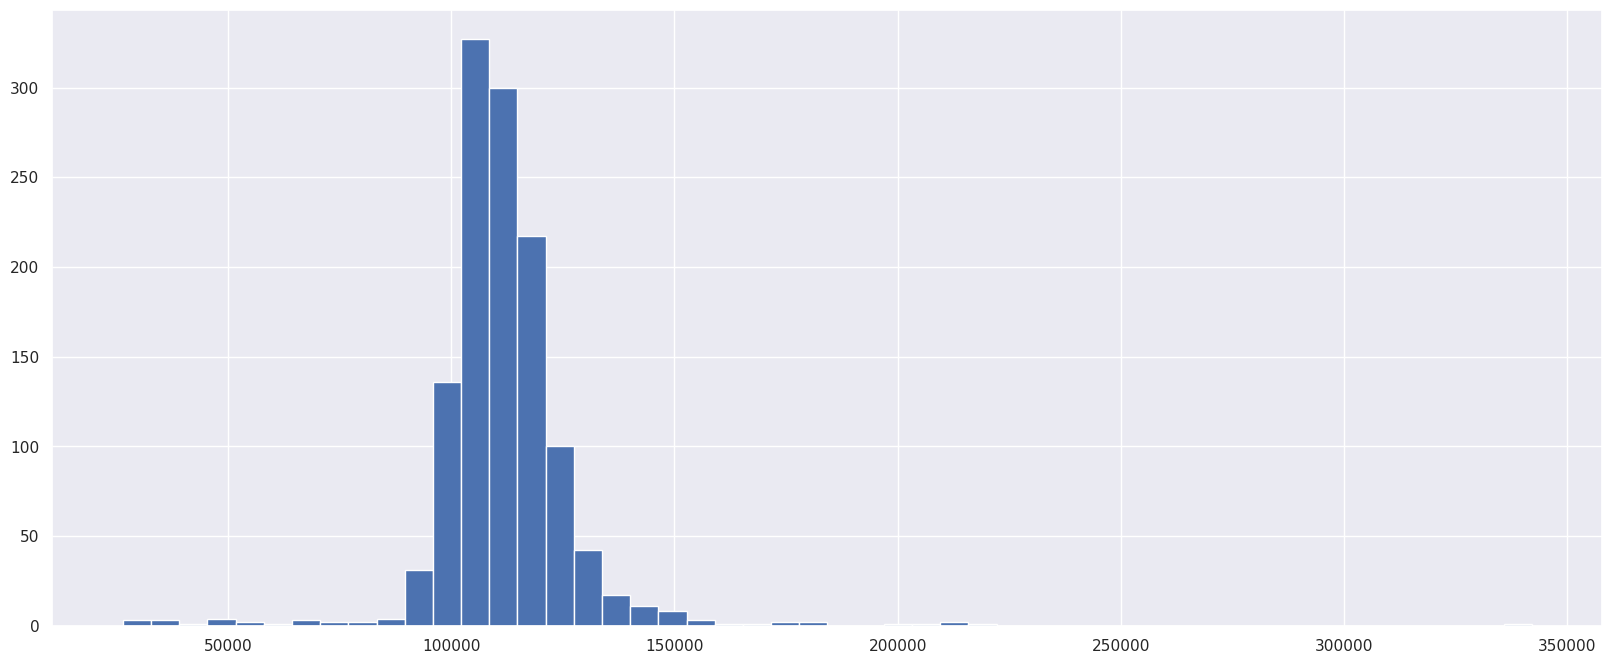

In [512]:
df['n_fragments'].hist(bins=50)

In [513]:
df

,contig,start,stop,strand,cell_type,fa,fa_length,n_fragments
gene_id,,,,,,,,
ENSG00000272602,chr4,49230,114766,+,none,"RegionFragmentArray(n_frags=142597, region=chr...",65536,142597
ENSG00000185627,chr11,232875,298411,+,all,"RegionFragmentArray(n_frags=125994, region=chr...",65536,125994
ENSG00000185885,chr11,309433,374969,+,all,"RegionFragmentArray(n_frags=146204, region=chr...",65536,146204
ENSG00000130731,chr16,574877,640413,-,all,"RegionFragmentArray(n_frags=113901, region=chr...",65536,113901
ENSG00000169020,chr4,612842,678378,-,all,"RegionFragmentArray(n_frags=211291, region=chr...",65536,211291
...,...,...,...,...,...,...,...,...
ENSG00000135902,chr2,232522104,232587640,+,none,"RegionFragmentArray(n_frags=118226, region=chr...",65536,118226
ENSG00000244474,chr2,233714693,233780229,+,gi,"RegionFragmentArray(n_frags=115849, region=chr...",65536,115849
ENSG00000182177,chr2,236202964,236268500,-,none,"RegionFragmentArray(n_frags=122924, region=chr...",65536,122924


In [514]:
import copy
from dataclasses import dataclass, field, replace
from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

# frag_h5 = FragmentsH5("/scratch/karius/finished.fragments.h5") # "/scratch/test_samples/SEQRUN48_LIBRARY577.fragments.h5")
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = metadata.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

@dataclass
class CoverageDifferenceTrack(CoverageTrack):
    def _build_coverage(self, *args, **kwargs):
        c1 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('+').get_midpoint_coverage_array() 
        c2 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('-').get_midpoint_coverage_array() 
        return c2 - c1

    def _plot(self, ax): 
        super()._plot(ax)
        ax.axhline(0)

def StrandSplitCoverageTrack(fa, *args, **kwargs):
    p1 = CoverageTrack(fa.subset_by_fragment_strand('+'), *args, color='black', **kwargs)
    p1.name = p1.name + ' - Fwd Strand'
    p2 = CoverageTrack(fa.subset_by_fragment_strand('-'), *args, color='green', **kwargs)
    p2.name = p2.name + ' - Rev Strand'
    return p1 + p2

def make_single_strand_tss_tracks(fa, include_vplot=False):
    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for fraction, sm_win in [((40, 60), 300), ((60, 100), 700), ((110, 500), 1500)]:
        for TrackCls in (StrandSplitCoverageTrack, CoverageDifferenceTrack):
            tracks.append(TrackCls(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=fraction, smooth_window=sm_win, ylim=(None, None),
                                    vlines=[VLine(x=4096)], 
                                    name=f'{fraction[0]} - {fraction[1]} bp Fraction)'))
    return tracks

In [523]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'all' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39948861 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

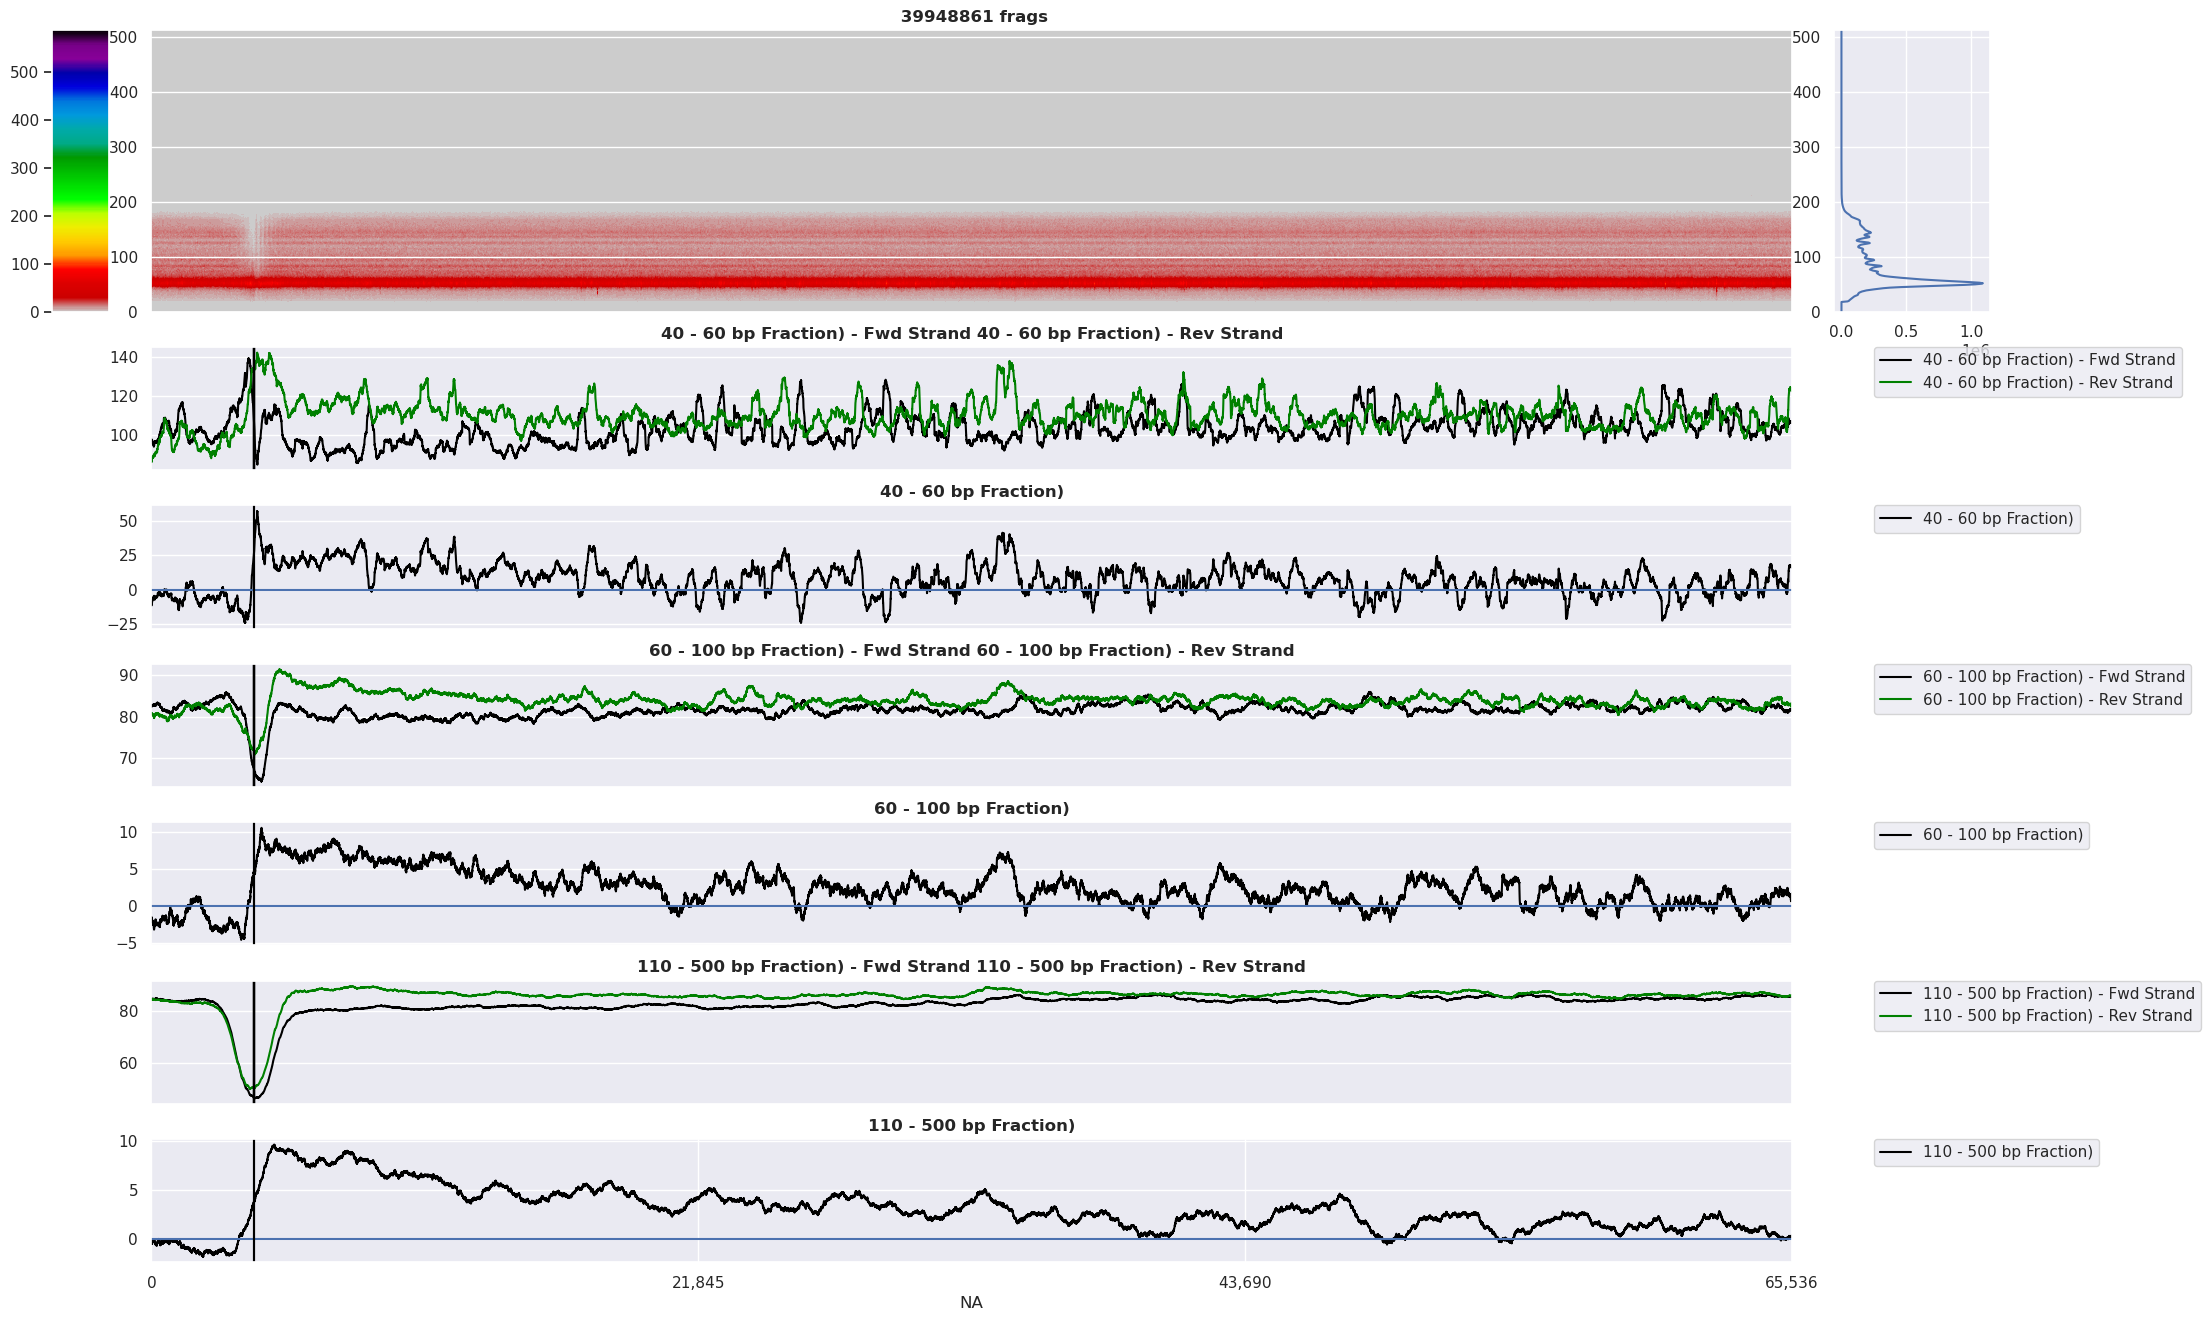

In [524]:
make_single_strand_tss_tracks(fa, True).plot()

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39951221 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

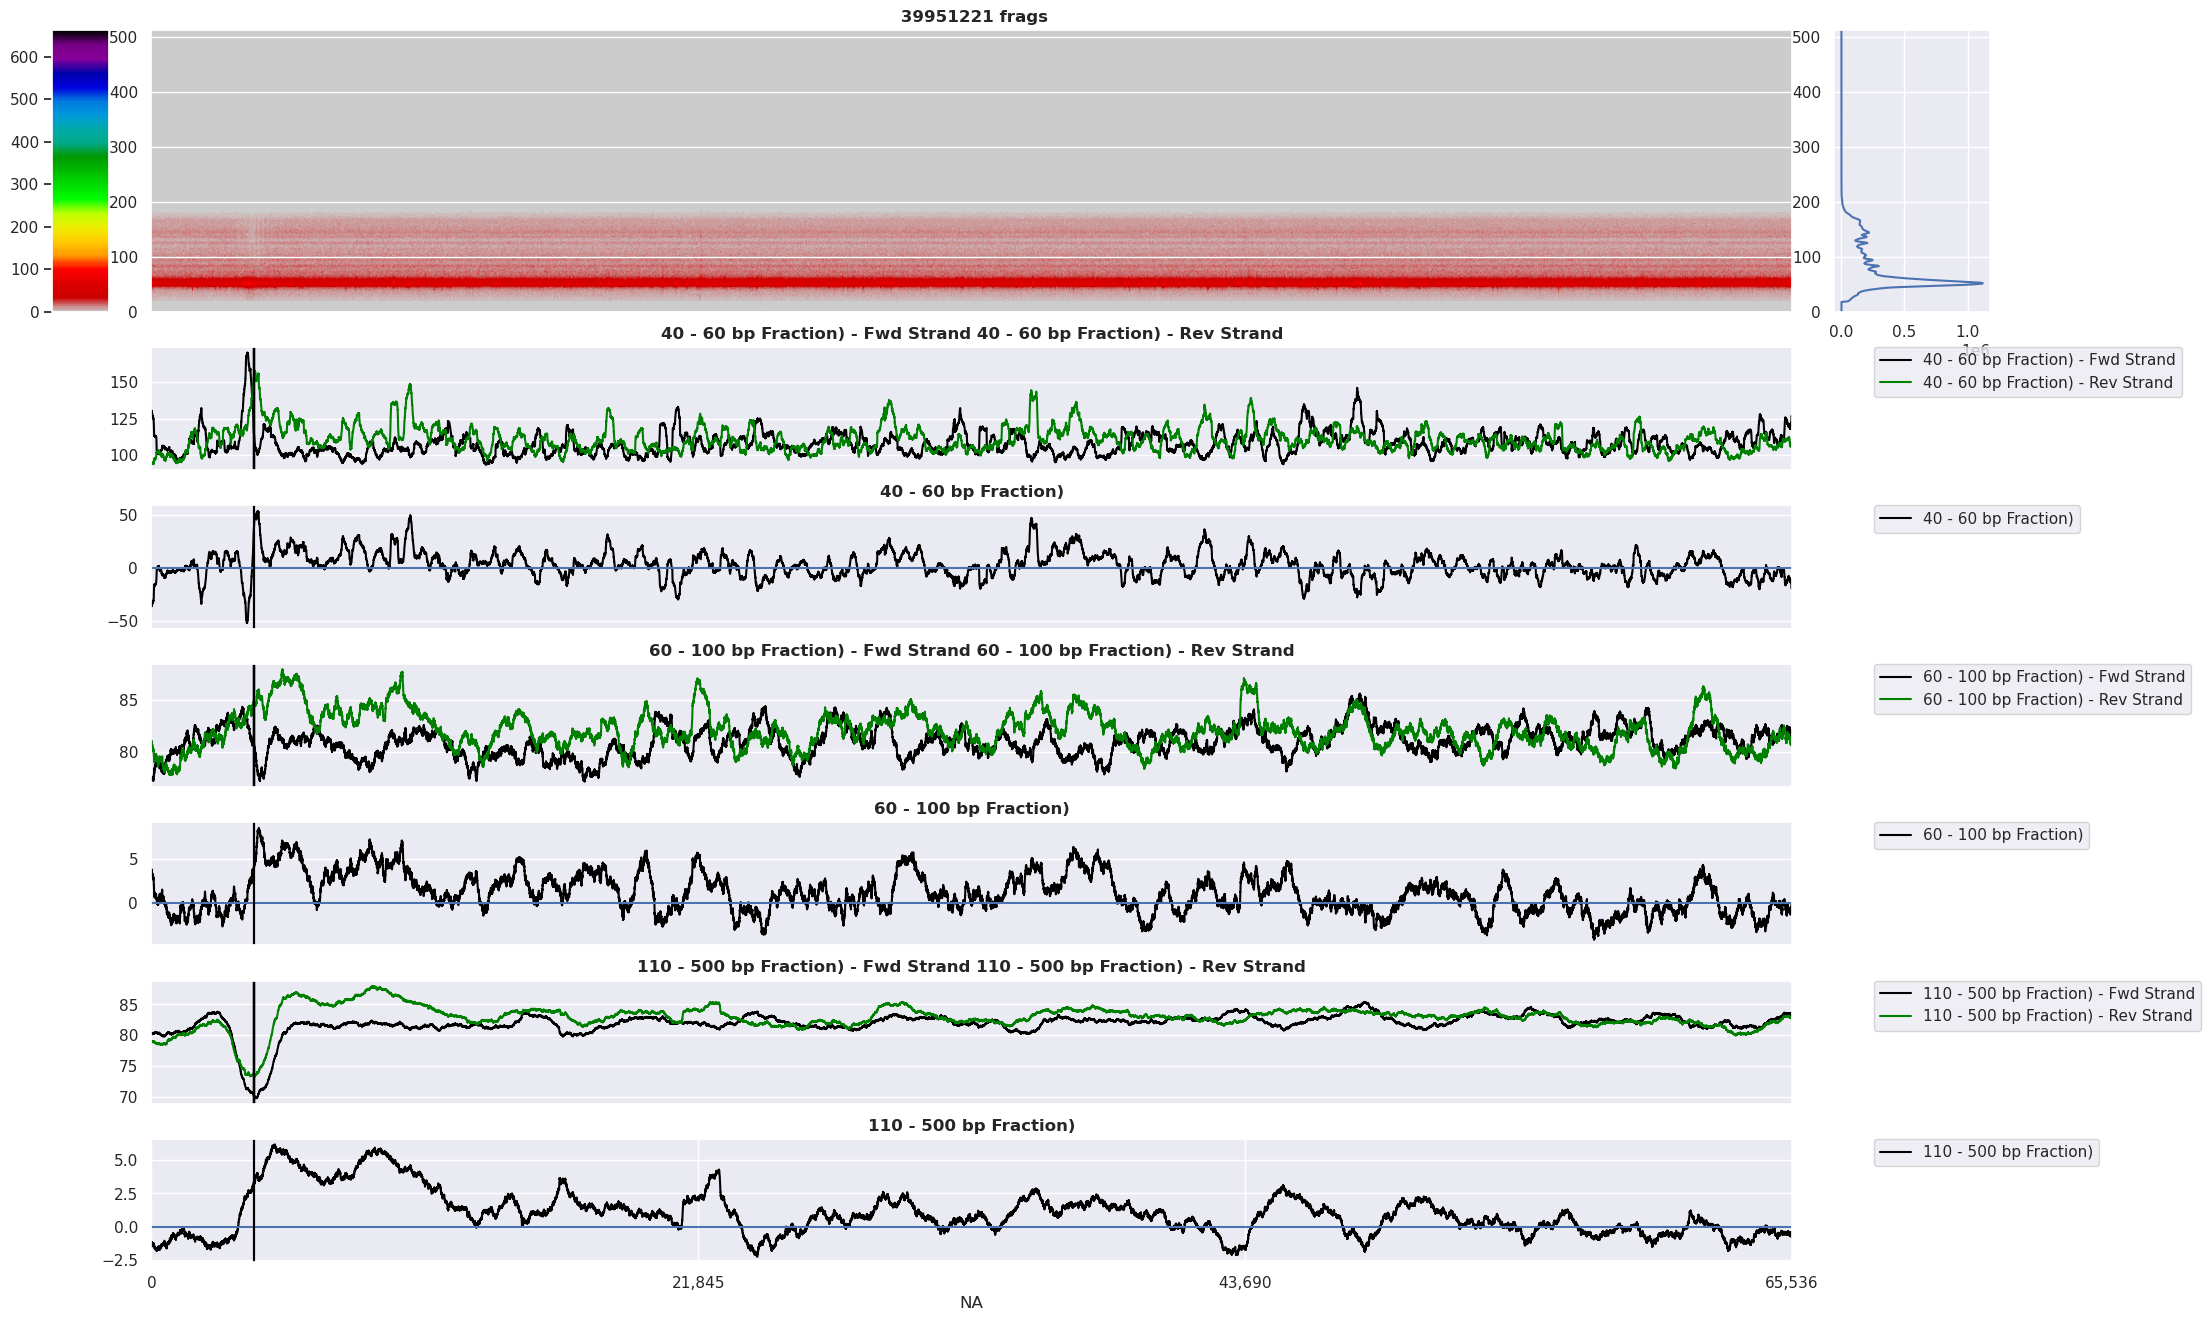

In [525]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'none' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 
make_single_strand_tss_tracks(fa, True).plot()

In [181]:
pd.DataFrame([.truncate(1024)fm.length for fm in fms]).hist(bins=100)

SyntaxError: invalid syntax (1376398094.py, line 1)

(<Figure size 2500x200 with 1 Axes>,
 [<AxesSubplot:title={'center':'coverage'}, xlabel='NA'>])

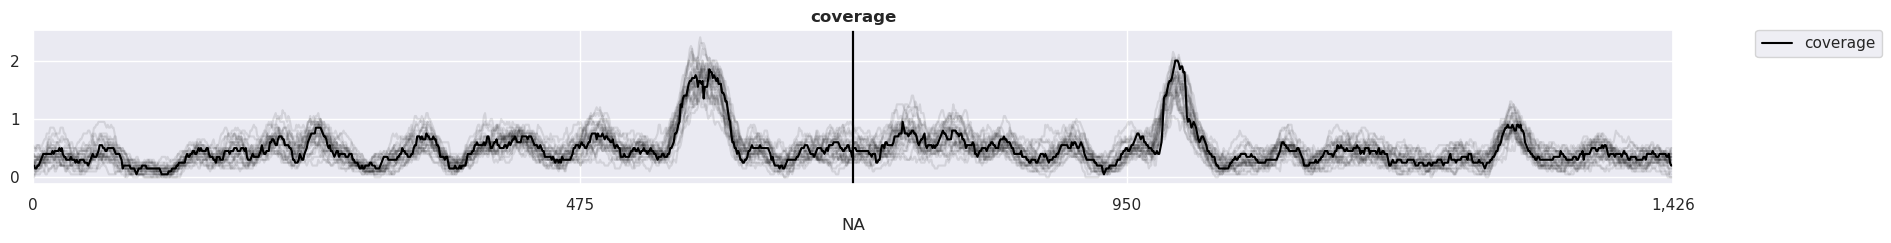

In [423]:
import scipy
tracks = fms[100].make_tracks()
del tracks[0]
tracks.plot()

In [282]:
df.query("strand == '+' and element == 'exon'")

,start,stop
gene_id,,
ENSG00000000005,"[100584936, 100585231, 100593895, 100594261, 1...","[100585066, 100585362, 100594035, 100594362, 1..."
ENSG00000000460,"[169794730, 169795040, 169795043, 169795409, 1...","[169794905, 169795115, 169795213, 169795983, 1..."
ENSG00000000971,"[196652043, 196652045, 196652056, 196672978, 1...","[196652175, 196652175, 196652175, 196673163, 1..."
ENSG00000001167,"[41072974, 41072983, 41079029, 41079029, 41080...","[41073084, 41073084, 41079164, 41079164, 41080..."
ENSG00000001461,"[24415802, 24415803, 24415813, 24415814, 24419...","[24415904, 24415904, 24415904, 24415904, 24419..."
...,...,...
ENSG00000289282,"[31623874, 31624261, 31624450, 31625171, 31625...","[31623909, 31624360, 31624522, 31625314, 31625..."
ENSG00000289325,[66926308],[66926346]
ENSG00000289360,[105040848],[105040925]


In [270]:
df.query("gene_id == 'ENSG00000289281'")

,contig,element,start,stop,strand,gene_id
1228392,chr16,exon,3004132,3004601,+,ENSG00000289281
1228398,chr16,five_prime_UTR,3004132,3004240,+,ENSG00000289281
1228395,chr16,exon,3004603,3004859,+,ENSG00000289281
